## Purpose

To explain why with large $\mathrm{Fst}$, that LDSC with fixed intercept is biased upwards. It is with the reference panel since the individual-level results do not have this issue.

In [1]:
import pandas as pd
import numpy as np
import scipy
import scipy.sparse as sp
import scipy.io as sio
import scipy.stats as stats
from tqdm.notebook import tqdm


import os
os.environ["R_HOME"] = f"{os.environ['CONDA_PREFIX']}\\Lib\\R"


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from plotnine import *

import matplotlib.pyplot as plt 

import pickle

from joblib import Parallel, delayed

import sys
from pathlib import Path

# Get project root as parent of notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.methods.GWASH_funcs import *
from src.methods.GWASH_sim_funcs import *
from src.methods.ldsc_barebones import *

from src.simtools.sim_utils import *
from src.simtools.data_generation import data_generation as data_generation
from src.simtools.data_preprocessing import data_preprocessing as data_preprocessing
from src.simtools.do_analysis import do_analysis as do_analysis
from src.simtools.run_simulations import run_simulations as run_simulations
from src.simtools.data_generation import gen_ref_ldscores_panel as gen_ref_ldscores_panel
from src.simtools.visualization import visualize

from natsort import natsorted

import pickle

seed_num = 123
np.random.seed(seed_num)

os.chdir(PROJECT_ROOT)

# $\mathrm{F_{st}}$ base case

## Individual Level

In [ ]:
seed_num = 2001


n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':False}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0.05

if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores,ref_mu2_hat = ref_mu2_hat,ref_mu3_hat = ref_mu3_hat)
num_sims = 100
res_dfs = []
for i in tqdm(range(num_sims)):
    res_dfs.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs = pd.concat(res_dfs).reset_index(drop = True)

In [ ]:
res_dfs.to_csv('save_data/experiment/realistic_Fst005_100sims.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['0.05'] = res_dfs
param = r'$\mathrm{Fst}$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, Individual-level, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

In [ ]:
ggsave(p,'figures/experiment/realistic_Fst005_100sims.png',dpi = 600)

## Reference Panel

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0.05

if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores,ref_mu2_hat = ref_mu2_hat,ref_mu3_hat = ref_mu3_hat)
res_dfs_ref_panel = []
num_sims = 100
for i in tqdm(range(num_sims)):
    res_dfs_ref_panel.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel = pd.concat(res_dfs_ref_panel).reset_index(drop = True)

In [ ]:
res_dfs_ref_panel.to_csv('save_data/experiment/realistic_Fst005_100sims_ref_panel.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['0.05'] = res_dfs_ref_panel
param = r'$\mathrm{Fst}$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, Ref_panel, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

In [ ]:
ggsave(p,'figures/experiment/realistic_Fst005_100sims_ref_panel.png',dpi = 600)

Differences in the reference panel compared to the sample data create this bias. Simulating with $\mathrm{Fst}$ make this even worse.

To illustrate the point further, let's say that you add and subtract a constant values of the LD Scores such that $\mu_{2}$ is unchanged. Here, $\mathrm{Fst} = 0$.

# Add/Subtract $C$ to LD Scores

## Sanity Check

I show that setting the seed to the reference panel to construct $\hat{\ell}_{j}$, $\hat{\mu}_{2}$, and $\hat{\mu}_{3}$ is the same as generating these from the sample genotype data.

This is so I do not have to change the source code to add/subtract $C$.

In [ ]:
seed_num = 2001

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True

i = 10
ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)


my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = None,ref_mu2_hat = None,ref_mu3_hat = None)
np.random.seed(seed_num + i)

X,b = my_data_gen.gen_X(realistic = realistic)
y = my_data_gen.gen_y(X,b)


my_data_preprocessing = data_preprocessing(my_data_gen,nPCs = nPCs,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC)
if regress_PC_out:
    regress_res = my_data_preprocessing.regress_out_PCs(X,y)
    X = regress_res['X_res']
    y = regress_res['y_res']
    
h2_samp_fve =  np.var(np.matmul(X,b),ddof=1)/np.var(y,ddof = 1)
if scaleX:
    X_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(X)
else:
    X_tilde = X
if scaley:
    y_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(y)
else:
    y_tilde = y
# if my_data_gen.ref_ldscores is None, then generate ldscores. Otherwise, use my_data_gen.ref_ldscores
u2,s2,ldscores = my_data_gen.compute_u2_ldscores(X_tilde,y_tilde)
ldsc_reg_weights = ldscores
sims = do_analysis(my_data_gen,X_tilde,u2,s2,ldscores,ldsc_reg_weights,calc_mu_hat_2_fast = True)
gwash_res_sample_theoretical = sims.do_GWASH_from_X_tilde() # Do same calculation from X_tilde() just to get theoretical variance.
gwash_mu2_hat = gwash_res_sample_theoretical['mu2_hat']
gwash_mu3_hat = gwash_res_sample_theoretical['mu3_hat']

assert(np.array_equal(ref_ldscores,ldscores)) # True
assert(ref_mu2_hat == gwash_mu2_hat) # True
assert(ref_mu3_hat == gwash_mu3_hat) # True

## Individual Level

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


n_jobs = 1

C = 0
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)


res_dfs_ref_panel_C = []
num_sims = 100

for i in tqdm(range(num_sims)):
    # I do not want to edit the src code to +/- C to the individual level LD Scores so I make the reference panel = the sample data (seed + i).
    if make_ref_ldscores:
        ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
        ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
        n_tilde = ref_data_gen.n
    else:
        ref_data_gen = None
        ref_ldscores = None
        n_tilde = None
    
        ref_mu2_hat = None
        ref_mu3_hat = None
        X_ref = None
    ref_ldscores_C = ref_ldscores + C_vec
    ref_mu2_hat_C = ref_ldscores_C.mean()
    my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)

    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_pm_0.txt',sep = '\t',index = None)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


n_jobs = 1

C = 5
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)


res_dfs_ref_panel_C = []
num_sims = 100

for i in tqdm(range(num_sims)):
    # I do not want to edit the src code to +/- C to the individual level LD Scores so I make the reference panel = the sample data for that seed.
    if make_ref_ldscores:
        ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
        ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
        n_tilde = ref_data_gen.n
    else:
        ref_data_gen = None
        ref_ldscores = None
        n_tilde = None
    
        ref_mu2_hat = None
        ref_mu3_hat = None
        X_ref = None
    ref_ldscores_C = ref_ldscores + C_vec
    ref_mu2_hat_C = ref_ldscores_C.mean()
    my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)

    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_pm_5.txt',sep = '\t',index = None)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


n_jobs = 1

C = 10
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)


res_dfs_ref_panel_C = []
num_sims = 100

for i in tqdm(range(num_sims)):
    # I do not want to edit the src code to +/- C to the individual level LD Scores so I make the reference panel = the sample data for that seed.
    if make_ref_ldscores:
        ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
        ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
        n_tilde = ref_data_gen.n
    else:
        ref_data_gen = None
        ref_ldscores = None
        n_tilde = None
    
        ref_mu2_hat = None
        ref_mu3_hat = None
        X_ref = None
    ref_ldscores_C = ref_ldscores + C_vec
    ref_mu2_hat_C = ref_ldscores_C.mean()
    my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)

    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_pm_10.txt',sep = '\t',index = None)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


n_jobs = 1

C = 15
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)


res_dfs_ref_panel_C = []
num_sims = 100

for i in tqdm(range(num_sims)):
    # I do not want to edit the src code to +/- C to the individual level LD Scores so I make the reference panel = the sample data for that seed.
    if make_ref_ldscores:
        ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
        ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
        n_tilde = ref_data_gen.n
    else:
        ref_data_gen = None
        ref_ldscores = None
        n_tilde = None
    
        ref_mu2_hat = None
        ref_mu3_hat = None
        X_ref = None
    ref_ldscores_C = ref_ldscores + C_vec
    ref_mu2_hat_C = ref_ldscores_C.mean()
    my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)

    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_pm_15.txt',sep = '\t',index = None)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


n_jobs = 1

C = 20
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)


res_dfs_ref_panel_C = []
num_sims = 100

for i in tqdm(range(num_sims)):
    # I do not want to edit the src code to p/m C to the individual level LD Scores so I make the reference panel = the sample data for that seed.
    if make_ref_ldscores:
        ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
        ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
        n_tilde = ref_data_gen.n
    else:
        ref_data_gen = None
        ref_ldscores = None
        n_tilde = None
    
        ref_mu2_hat = None
        ref_mu3_hat = None
        X_ref = None
    ref_ldscores_C = ref_ldscores + C_vec
    ref_mu2_hat_C = ref_ldscores_C.mean()
    my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)

    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_pm_20.txt',sep = '\t',index = None)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


n_jobs = 1

C = 25
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)


res_dfs_ref_panel_C = []
num_sims = 100

for i in tqdm(range(num_sims)):
    # I do not want to edit the src code to p/m C to the individual level LD Scores so I make the reference panel = the sample data for that seed.
    if make_ref_ldscores:
        ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
        ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
        n_tilde = ref_data_gen.n
    else:
        ref_data_gen = None
        ref_ldscores = None
        n_tilde = None
    
        ref_mu2_hat = None
        ref_mu3_hat = None
        X_ref = None
    ref_ldscores_C = ref_ldscores + C_vec
    ref_mu2_hat_C = ref_ldscores_C.mean()
    my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)

    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_pm_25.txt',sep = '\t',index = None)

### Sanity Check

In [12]:
res_ref_pm_0 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_15.txt')
res_indiv_pm_0 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_pm_15.0.txt')

res_ref_pm_0['h2_ldsc_fixed'] - res_indiv_pm_0['h2_ldsc_fixed']

0     0.000801
1    -0.000728
2     0.001367
3     0.000043
4    -0.001219
        ...   
95    0.002810
96    0.000666
97    0.002538
98   -0.001414
99   -0.001410
Name: h2_ldsc_fixed, Length: 100, dtype: float64

### Visualization

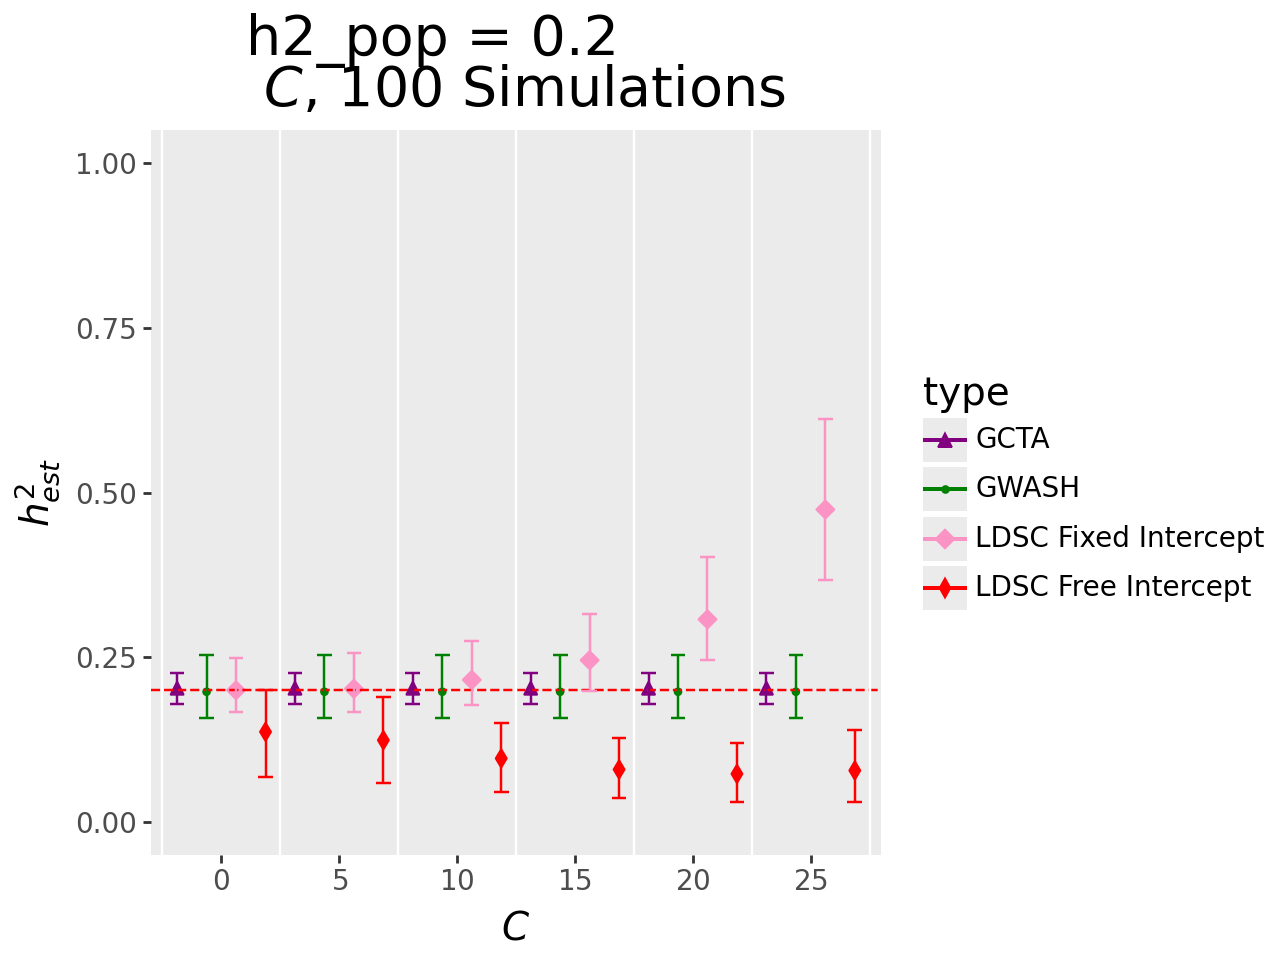

In [2]:
res_pm_0 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_pm_0.0.txt')
res_pm_5 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_pm_5.0.txt')
res_pm_10 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_pm_10.0.txt')
res_pm_15 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_pm_15.0.txt')
res_pm_20 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_pm_20.0.txt')
res_pm_25 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_pm_25.0.txt')

res_dict_raw = dict()
res_dict_raw[r'$0$'] = res_pm_0
res_dict_raw[r'$5$'] = res_pm_5
res_dict_raw[r'$10$'] = res_pm_10
res_dict_raw[r'$15$'] = res_pm_15
res_dict_raw[r'$20$'] = res_pm_20
res_dict_raw[r'$25$'] = res_pm_25
param = r'$C$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

## Reference Panel

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1

C = 0
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)

ref_ldscores_C = ref_ldscores + C_vec
ref_mu2_hat_C = ref_ldscores_C.mean()
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)
res_dfs_ref_panel_C = []
num_sims = 100
for i in tqdm(range(num_sims)):
    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

In [ ]:
res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_0.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['0'] = res_dfs_ref_panel_C
param = r'$\hat{\ell}_{j} \pm 0$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

In [ ]:
ggsave(p,'figures/experiment/realistic_Fst0_100sims_ref_panel_pm_0.png',dpi = 600)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1

C = 5
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)

ref_ldscores_C = ref_ldscores + C_vec
ref_mu2_hat_C = ref_ldscores_C.mean()
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)
res_dfs_ref_panel_C = []
num_sims = 100
for i in tqdm(range(num_sims)):
    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

In [ ]:
res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_5.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['5'] = res_dfs_ref_panel_C
param = r'$\hat{\ell}_{j} \pm 5$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

In [ ]:
ggsave(p,'figures/experiment/realistic_Fst0_100sims_ref_panel_pm_5.png',dpi = 600)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1

C = 10
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)

ref_ldscores_C = ref_ldscores + C_vec
ref_mu2_hat_C = ref_ldscores_C.mean()
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)
res_dfs_ref_panel_C = []
num_sims = 100
for i in tqdm(range(num_sims)):
    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_10.txt',sep = '\t',index = None)

In [ ]:
res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_10.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['10'] = res_dfs_ref_panel_C
param = r'$\hat{\ell}_{j} \pm 10$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

In [ ]:
ggsave(p,'figures/experiment/realistic_Fst0_100sims_ref_panel_pm_10.png',dpi = 600)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1

C = 15
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)

ref_ldscores_C = ref_ldscores + C_vec
ref_mu2_hat_C = ref_ldscores_C.mean()
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)
res_dfs_ref_panel_C = []
num_sims = 100
for i in tqdm(range(num_sims)):
    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_15.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['15'] = res_dfs_ref_panel_C
param = r'$\hat{\ell}_{j} \pm 15$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

ggsave(p,'figures/experiment/realistic_Fst0_100sims_ref_panel_pm_15.png',dpi = 600)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1

C = 20
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)

ref_ldscores_C = ref_ldscores + C_vec
ref_mu2_hat_C = ref_ldscores_C.mean()
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)
res_dfs_ref_panel_C = []
num_sims = 100
for i in tqdm(range(num_sims)):
    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_20.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['20'] = res_dfs_ref_panel_C
param = r'$\hat{\ell}_{j} \pm 20$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

ggsave(p,'figures/experiment/realistic_Fst0_100sims_ref_panel_pm_20.png',dpi = 600)

In [ ]:
seed_num = 2001

i = np.random.choice(np.arange(0,1000,1),size = 1).item()

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


counter += 1
Fsts = [0,0.01,0.03,0.05,0.07,0.1]
Fst = 0


if make_ref_ldscores:
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = 123,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    n_tilde = ref_data_gen.n
else:
    ref_data_gen = None
    ref_ldscores = None
    n_tilde = None

    ref_mu2_hat = None
    ref_mu3_hat = None
    X_ref = None

n_jobs = 1

C = 25
C_vec = np.concatenate([np.repeat(C,5000),np.repeat(-C,5000)]).reshape(-1,1)

ref_ldscores_C = ref_ldscores + C_vec
ref_mu2_hat_C = ref_ldscores_C.mean()
    
my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = ref_ldscores_C,ref_mu2_hat = ref_mu2_hat_C,ref_mu3_hat = ref_mu3_hat)
res_dfs_ref_panel_C = []
num_sims = 100
for i in tqdm(range(num_sims)):
    res_dfs_ref_panel_C.append(run_simulations(my_data_gen,seed = seed_num,scaleX = scaleX,scaley = scaley,num_sims = num_sims,nPCs = nPCs,regress_PC_out = regress_PC_out,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC, multithreading = multithreading, n_jobs = n_jobs, realistic = realistic, calc_mu_hat_2_fast = calc_mu_hat_2_fast,reml_tol = reml_tol,track_progress = track_progress).run_single_simulation_publication(i=i))

res_dfs_ref_panel_C = pd.concat(res_dfs_ref_panel_C).reset_index(drop = True)

In [ ]:
res_dfs_ref_panel_C.to_csv('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_25.txt',sep = '\t',index = None)

In [ ]:
res_dict_raw = dict()
res_dict_raw['25'] = res_dfs_ref_panel_C
param = r'$\hat{\ell}_{j} \pm 25$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

In [ ]:
ggsave(p,'figures/experiment/realistic_Fst0_100sims_ref_panel_pm_25.png',dpi = 600)

### Another View

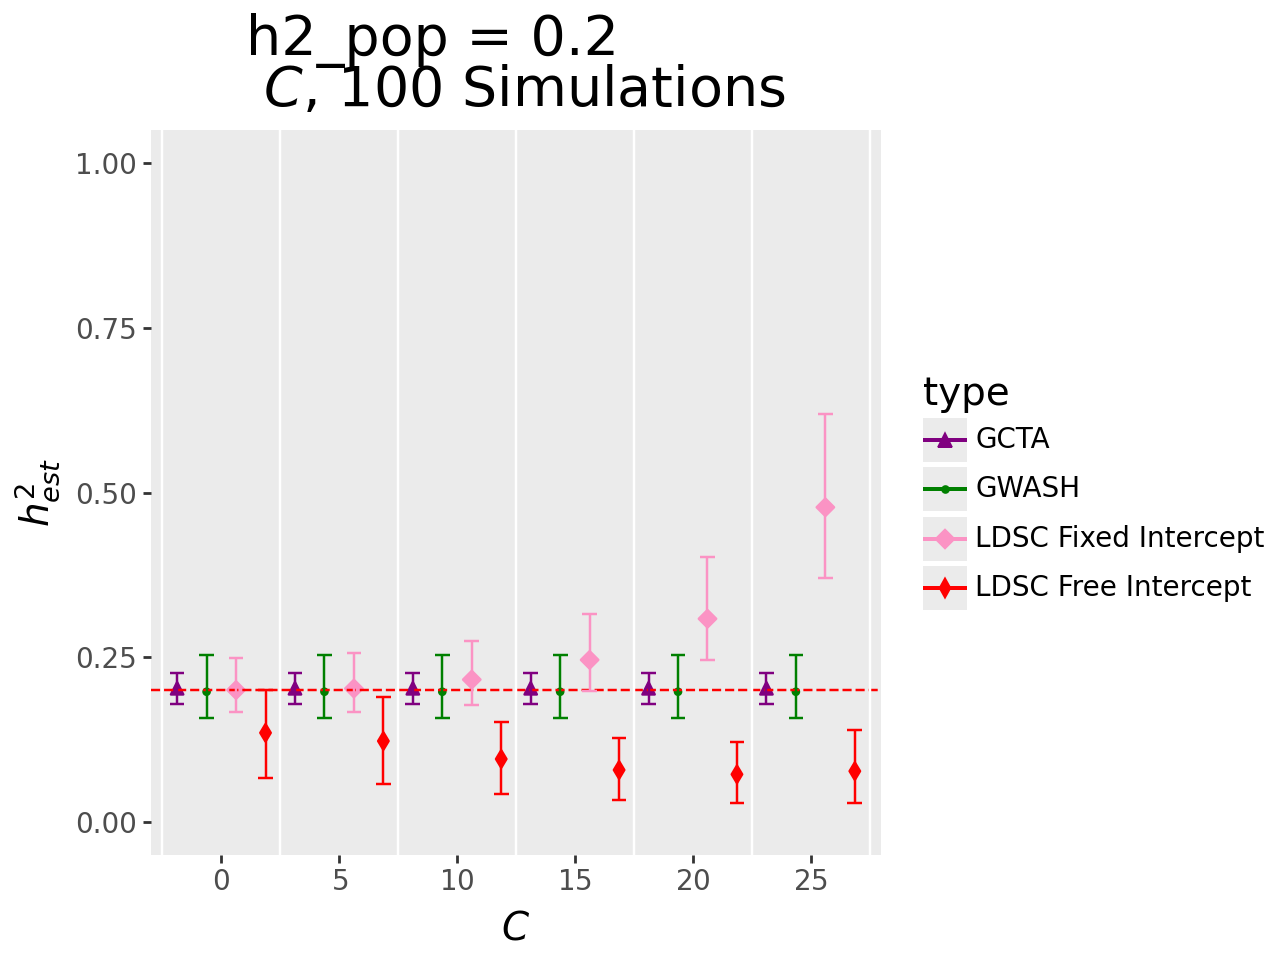

In [3]:
res_pm_0 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_0.txt')
res_pm_5 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_5.txt')
res_pm_10 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_10.txt')
res_pm_15 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_15.txt')
res_pm_20 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_20.txt')
res_pm_25 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_25.txt')

res_dict_raw = dict()
res_dict_raw[r'$0$'] = res_pm_0
res_dict_raw[r'$5$'] = res_pm_5
res_dict_raw[r'$10$'] = res_pm_10
res_dict_raw[r'$15$'] = res_pm_15
res_dict_raw[r'$20$'] = res_pm_20
res_dict_raw[r'$25$'] = res_pm_25
param = r'$C$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + axis_labels + title
p

In [4]:
ggsave(p,'figures/experiment/realistic_Fst0_100sims_ref_panel_pm_C_all.png',dpi = 600)

In [ ]:
avg_h2_fixed = [res_pm_0.mean(axis = 0)['h2_ldsc_fixed'],
res_pm_5.mean(axis = 0)['h2_ldsc_fixed'],
res_pm_10.mean(axis = 0)['h2_ldsc_fixed'],
res_pm_15.mean(axis = 0)['h2_ldsc_fixed'],
res_pm_20.mean(axis = 0)['h2_ldsc_fixed'],
res_pm_25.mean(axis = 0)['h2_ldsc_fixed']]

bias = [z - 0.2 for z in avg_h2_fixed]
pm_Cs  = [0,5,10,15,20,25]

df = pd.DataFrame([pm_Cs,bias]).T

df.columns = ['pm_Cs','bias']


ggplot(aes(x = 'pm_Cs',y = 'bias')) + geom_point() +geom_hline(yintercept=0,color = 'red',linetype='--')

# Population Stratification

I want to check to see if $\chi^{2}_{j}$ are actually inflated by the intercept term

In [ ]:
seed_num = 2001

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True


Fst = 0.1
sigma_s = 0.8

num_sims = 1000

u2_from_sims = dict()
h2_from_sims = dict()
for i in tqdm(range(num_sims)):
    u2_res = np.zeros((m,5))
    h2_res = np.zeros((1,3))
    ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
    ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)
    
    
    my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = None,ref_mu2_hat = None,ref_mu3_hat = None)
    np.random.seed(seed_num + i)
    
    X,b = my_data_gen.gen_X(realistic = realistic)
    y = my_data_gen.gen_y(X,b)
    
    
    my_data_preprocessing = data_preprocessing(my_data_gen,nPCs = nPCs,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC)
    if regress_PC_out:
        regress_res = my_data_preprocessing.regress_out_PCs(X,y)
        X = regress_res['X_res']
        y = regress_res['y_res']
        
    h2_samp_fve =  np.var(np.matmul(X,b),ddof=1)/np.var(y,ddof = 1)
    if scaleX:
        X_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(X)
    else:
        X_tilde = X
    if scaley:
        y_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(y)
    else:
        y_tilde = y
    S = np.concatenate([np.repeat(sigma_s,n/2),np.repeat(-sigma_s,n/2)]).reshape(-1,1)
    pop_strat_term = (1/n)*((X_tilde.T @ S)**2) # hidden usually
    
    # if my_data_gen.ref_ldscores is None, then generate ldscores. Otherwise, use my_data_gen.ref_ldscores
    u2,s2,ldscores = my_data_gen.compute_u2_ldscores(X_tilde,y_tilde)
    ldsc_reg_weights = ldscores
    sims = do_analysis(my_data_gen,X_tilde,u2,s2,ldscores,ldsc_reg_weights,calc_mu_hat_2_fast = True)
    sims_fixed = do_analysis(my_data_gen,X_tilde,u2,s2,ldscores,ldsc_reg_weights,intercept = 1,calc_mu_hat_2_fast = True)
    
    gwash_res_sample_theoretical = sims.do_GWASH_from_X_tilde() # Do same calculation from X_tilde() just to get theoretical variance.
    #gwash_mu2_hat = gwash_res_sample_theoretical['mu2_hat']
    #gwash_mu3_hat = gwash_res_sample_theoretical['mu3_hat']
    h2_ldsc_reg,se_ldsc_reg,icpt_ldsc_reg,weights = sims.do_ldsc()
    h2_res[0,0] = h2_ldsc_reg
    h2_ldsc_fixed,se_ldsc_fixed,icpt_ldsc_fixed,weights = sims_fixed.do_ldsc()
    h2_res[0,1] = h2_ldsc_fixed

    
    
    pop_strat_term = (1/n)*((X_tilde.T @ S)**2)
    
    #gwash_h2_est = gwash_res_sample_theoretical['gwash']

    u2_res[:,0] = u2.flatten() # True

    u2_from_ldsc = h2_ldsc_reg*(((n/m) * ldscores)) +  icpt_ldsc_reg
    u2_res[:,1] = u2_from_ldsc.flatten() # ldsc_reg
    
    u2_from_ldsc_fixed = h2_ldsc_fixed*(((n/m) * ldscores)) +  icpt_ldsc_fixed
    u2_res[:,2] = u2_from_ldsc_fixed.flatten() # ldsc_fixed
    
    u2_theory = h2_ldsc_fixed*(((n/m) * ldscores) - 1) + (1 - (sigma_s**2)) + pop_strat_term 
    u2_res[:,3] = u2_theory.flatten() # ldsc with new pop strat term

    u2_new = u2 - pop_strat_term + (sigma_s**2) # take u2 and subtract by pop_strat_term
    s2_new = u2_new.mean()
    h2_ldsc_theory,se_ldsc_theory,icpt_ldsc_theory,weights = do_analysis(my_data_gen,X_tilde,u2_new,s2_new,ldscores,ldsc_reg_weights,intercept = 1,calc_mu_hat_2_fast = True).do_ldsc()
    h2_res[0,2] = h2_ldsc_theory
    
    u2_w_correct_h2 = h2_pop*(((n/m) * ldscores) - 1) + (1 - (sigma_s**2)) + pop_strat_term
    u2_res[:,4] = u2_w_correct_h2.flatten() # suppose that the heritability that was estimated is h2_pop. What would be the MSE of the u2s in comparison?
    
    u2_from_sims[str(i)] = u2_res
    h2_from_sims[str(i)] = h2_res
    
    
    


  1%|▊                                                                             | 10/1000 [01:50<3:02:02, 11.03s/it]

In [139]:
h2_npy = np.concat([z for z in h2_from_sims.values()],axis = 0)

h2_df = pd.DataFrame(h2_npy)
h2_df.columns = ['ldsc_free','ldsc_fixed','theory']

h2_df.to_csv('save_data/experiment/realistic_Fst01_sigma_s08_theory_validation.txt',sep = "\t")
bias_df = h2_npy - 0.2
bias_df = pd.DataFrame(bias_df)

bias_df.columns = ['ldsc_free','ldsc_fixed','theory']
bias_df['sim'] = [z for z in range(num_sims)]
bias_melt = pd.melt(bias_df,id_vars = ['sim'])
breaks = ['ldsc_free','ldsc_fixed','theory']
breaks_legend = ['LDSC Fixed Intercept','LDSC Free Intercept','LDSC Fixed Adjusted'] #ordered h2s
p = ggplot(bias_melt,aes(x = 'sim',y = 'value',color = 'variable')) + geom_line(aes(linetype = 'variable',size='variable')) + geom_hline(yintercept = 0,linetype = '--', color ='red') + ylab('bias ' + r'$(\hat{h} - h^{2}_{g})$') + scale_color_manual(values = ['#FB93C4','red','blue'],labels = breaks_legend) + scale_linetype_manual([':',':','-'],labels = breaks_legend) +scale_size_manual(values=[1.5, 0.5, 0.5],labels = breaks_legend) + theme(legend_position = 'bottom', legend_title = element_blank())

ggsave(p,"figures/experiment/realistic_Fst01_sigma_s08_bias_correction_100sim.jpg",dpi = 600)

In [141]:
h2_npy = np.concat([z for z in h2_from_sims.values()],axis = 0)

h2_df = pd.DataFrame(h2_npy)
h2_df.columns = ['ldsc_free','ldsc_fixed','theory']

h2_df.to_csv('save_data/experiment/realistic_Fst005_sigma_s04_theory_validation.txt',sep = "\t")
bias_df = h2_npy - 0.2
bias_df = pd.DataFrame(bias_df)

bias_df.columns = ['ldsc_free','ldsc_fixed','theory']
bias_df['sim'] = [z for z in range(num_sims)]
bias_melt = pd.melt(bias_df,id_vars = ['sim'])
breaks = ['ldsc_free','ldsc_fixed','theory']
breaks_legend = ['LDSC Fixed Intercept','LDSC Free Intercept','LDSC Fixed Adjusted'] #ordered h2s
p = ggplot(bias_melt,aes(x = 'sim',y = 'value',color = 'variable')) + geom_line(aes(linetype = 'variable',size='variable')) + geom_hline(yintercept = 0,linetype = '--', color ='red') + ylab('bias ' + r'$(\hat{h} - h^{2}_{g})$') + scale_color_manual(values = ['#FB93C4','red','blue'],labels = breaks_legend) + scale_linetype_manual([':',':','-'],labels = breaks_legend) +scale_size_manual(values=[1.5, 0.5, 0.5],labels = breaks_legend) + theme(legend_position = 'bottom', legend_title = element_blank())

ggsave(p,"figures/experiment/realistic_Fst005_sigma_s04_bias_correction_100sim.jpg",dpi = 600)

In [140]:
h2_npy = pd.read_table('save_data/experiment/realistic_Fst0_sigma_s0_theory_validation.txt').iloc[:,[1,2,3]].to_numpy()

bias_df = h2_npy - 0.2
bias_df = pd.DataFrame(bias_df)

bias_df.columns = ['ldsc_free','ldsc_fixed','theory']
bias_df['sim'] = [z for z in range(num_sims)]
bias_melt = pd.melt(bias_df,id_vars = ['sim'])
breaks = ['ldsc_free','ldsc_fixed','theory']
breaks_legend = ['LDSC Fixed Intercept','LDSC Free Intercept','LDSC Fixed Adjusted'] #ordered h2s
p = ggplot(bias_melt,aes(x = 'sim',y = 'value',color = 'variable')) + geom_line(aes(linetype = 'variable',size='variable')) + geom_hline(yintercept = 0,linetype = '--', color ='red') + ylab('bias ' + r'$(\hat{h} - h^{2}_{g})$') + scale_color_manual(values = ['#FB93C4','red','blue'],labels = breaks_legend) + scale_linetype_manual([':',':','-'],labels = breaks_legend) +scale_size_manual(values=[1.5, 0.5, 0.5],labels = breaks_legend) + theme(legend_position = 'bottom', legend_title = element_blank())

ggsave(p,"figures/experiment/realistic_Fst0_sigma_s0_bias_correction_100sim.jpg",dpi = 600)

# Fst and Conditioning

In [8]:
seed_num = 2001

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': True,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True

i = 0
Fst = 0
ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)


my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = None,ref_mu2_hat = None,ref_mu3_hat = None)
np.random.seed(seed_num + i)

X,b = my_data_gen.gen_X(realistic = realistic)
X_orig = X.copy() # preserve X with no Fst
y = my_data_gen.gen_y(X,b)


my_data_preprocessing = data_preprocessing(my_data_gen,nPCs = nPCs,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC)
if regress_PC_out:
    regress_res = my_data_preprocessing.regress_out_PCs(X,y)
    X = regress_res['X_res']
    y = regress_res['y_res']
    
h2_samp_fve =  np.var(np.matmul(X,b),ddof=1)/np.var(y,ddof = 1)
if scaleX:
    X_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(X)
else:
    X_tilde = X
if scaley:
    y_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(y)
else:
    y_tilde = y
# # if my_data_gen.ref_ldscores is None, then generate ldscores. Otherwise, use my_data_gen.ref_ldscores
# u2,s2,ldscores = my_data_gen.compute_u2_ldscores(X_tilde,y_tilde)
# ldsc_reg_weights = ldscores
# sims = do_analysis(my_data_gen,X_tilde,u2,s2,ldscores,ldsc_reg_weights,calc_mu_hat_2_fast = True)
# gwash_res_sample_theoretical = sims.do_GWASH_from_X_tilde() # Do same calculation from X_tilde() just to get theoretical variance.
# gwash_mu2_hat = gwash_res_sample_theoretical['mu2_hat']
# gwash_mu3_hat = gwash_res_sample_theoretical['mu3_hat']

# assert(np.array_equal(ref_ldscores,ldscores)) # True
# assert(ref_mu2_hat == gwash_mu2_hat) # True
# assert(ref_mu3_hat == gwash_mu3_hat) # True




In [28]:
import statsmodels.formula.api as smf

### Add Fst manually
intercepts,slopes,MSEs,cond_nums = [],[],[],[]

Fsts = np.linspace(0,0.1,100)
for Fst in tqdm(Fsts):
    X = X_orig.copy()
    f = np.random.normal(loc = 0, scale = np.sqrt(Fst),size = m).reshape(1,-1)
    if n % 2 == 0:
        n1 = int(n/2)
        n2 = n
    else:
        n1 = int(np.round(n/2))#force n1 to have the odd number of subjects
        n2 = n - n1 # and n2 to have the rest
    
    ## NOW SPLIT THE MATRIX INTO TWO PARTS!
    X[:n1,] = X[:n1,] + f
    X[n1:,] = X[n1:,] - f
    
    X = np.divide(X,np.sqrt(1 + f**2).reshape(1,-1))
    y = my_data_gen.gen_y(X,b)

    X_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(X)
    y_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(y)

    u2,s2,ldscores = my_data_gen.compute_u2_ldscores(X_tilde,y_tilde)
    lj_chi2_df = pd.DataFrame([u2.flatten(),ldscores.flatten()]).T
    lj_chi2_df.columns = ['chi2','lj']
    
    model = smf.ols(formula='chi2 ~ lj', data=lj_chi2_df).fit()

    intercepts.append(model.params['Intercept'].item())
    slopes.append(model.params['lj'].item())
    MSEs.append(np.mean((u2 - model.predict())**2))
    cond_nums.append(model.condition_number)
    

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [06:46<00:00,  4.07s/it]


In [33]:
realistic_cond = pd.DataFrame(cond_nums)
realistic_cond.columns = ['condition_number']
realistic_cond['type'] = 'realistic'
realistic_cond['Fst'] = Fsts

realistic_cond

,condition_number,type,Fst
0,153.733221,realistic,0.00000
1,153.493185,realistic,0.00101
2,153.392990,realistic,0.00202
3,153.386133,realistic,0.00303
4,153.486756,realistic,0.00404
...,...,...,...
95,209.406528,realistic,0.09596
96,211.752638,realistic,0.09697
97,216.117853,realistic,0.09798
98,216.130897,realistic,0.09899


In [34]:
seed_num = 2001

n = 5000

X_properties = {'n': n,'m':10000,'pm_causal':None,'fixed_m_causal': False,'sigma_s':0, 'rho1':0.995,'rho2':None,'Fst':0}
ref_X_properties = {'ref_n': n,'ref_pm_causal':None,'ref_fixed_m_causal': False,'ref_sigma_s':0, 'ref_rho1':0.995,'ref_rho2':None,'ref_Fst':0}
ld_mat_properties = {'realistic': False,'model_Fst_in_realistic':True,'prefix': '1kg_p1_eur_ben/1kg_p1_eur_chr22','make_ref_ldscores':True}
method_properties = {'reml_tol': 1e-8,'reml_max_iters': 100}
stats_properties = {'scaleX': True,'scaley': True, 'nPCs':5,'regress_PC_out':False,'regress_X_on_PC': False,'regress_y_on_PC': False}
simul_properties = {'num_sims':np.nan,'h2_pop': 0.2}
debug_properties = {'calc_mu_hat_2_fast': True,'old':False,'track_progress':True}

list_of_dicts = [X_properties,ref_X_properties,ld_mat_properties,method_properties,stats_properties,simul_properties,debug_properties]
params  = combine_all_dicts(list_of_dicts)

to_run = dict()
to_run['demonstration'] = params

sim_key = 'demonstration'
locals().update(to_run[sim_key])
res_dict = dict()
res_dict_raw = dict()

#rhos = [0.995]
counter = -1
multithreading = True

i = 0
Fst = 0
ref_data_gen = data_generation(n = ref_n,m= m,Fst = Fst,rho1 = ref_rho1,rho2 = ref_rho2,sigma_s = ref_sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = ref_fixed_m_causal, old = old,realistic = realistic,prefix = prefix,use_gwash_m = False)
ref_ldscores,ref_mu2_hat,ref_mu3_hat,X_ref = gen_ref_ldscores_panel(ref_data_gen,seed = seed_num + i,nPCs = nPCs, regress_X_on_PC = regress_X_on_PC, regress_y_on_PC = regress_y_on_PC)


my_data_gen = data_generation(n = n,m= m,Fst = Fst,rho1 = rho1,rho2 = rho2,sigma_s = sigma_s,h2_pop = h2_pop,pm_causal = pm_causal,fixed_m_causal = fixed_m_causal, old = old,model_Fst_in_realistic = model_Fst_in_realistic,realistic = realistic,prefix = prefix,ref_ldscores = None,ref_mu2_hat = None,ref_mu3_hat = None)
np.random.seed(seed_num + i)

X,b = my_data_gen.gen_X(realistic = realistic)
X_orig = X.copy() # preserve X with no Fst
y = my_data_gen.gen_y(X,b)


my_data_preprocessing = data_preprocessing(my_data_gen,nPCs = nPCs,regress_X_on_PC = regress_X_on_PC,regress_y_on_PC = regress_y_on_PC)
if regress_PC_out:
    regress_res = my_data_preprocessing.regress_out_PCs(X,y)
    X = regress_res['X_res']
    y = regress_res['y_res']
    
h2_samp_fve =  np.var(np.matmul(X,b),ddof=1)/np.var(y,ddof = 1)
if scaleX:
    X_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(X)
else:
    X_tilde = X
if scaley:
    y_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(y)
else:
    y_tilde = y
# # if my_data_gen.ref_ldscores is None, then generate ldscores. Otherwise, use my_data_gen.ref_ldscores
# u2,s2,ldscores = my_data_gen.compute_u2_ldscores(X_tilde,y_tilde)
# ldsc_reg_weights = ldscores
# sims = do_analysis(my_data_gen,X_tilde,u2,s2,ldscores,ldsc_reg_weights,calc_mu_hat_2_fast = True)
# gwash_res_sample_theoretical = sims.do_GWASH_from_X_tilde() # Do same calculation from X_tilde() just to get theoretical variance.
# gwash_mu2_hat = gwash_res_sample_theoretical['mu2_hat']
# gwash_mu3_hat = gwash_res_sample_theoretical['mu3_hat']

# assert(np.array_equal(ref_ldscores,ldscores)) # True
# assert(ref_mu2_hat == gwash_mu2_hat) # True
# assert(ref_mu3_hat == gwash_mu3_hat) # True
import statsmodels.formula.api as smf

### Add Fst manually
intercepts,slopes,MSEs,cond_nums = [],[],[],[]

Fsts = np.linspace(0,0.1,100)
for Fst in tqdm(Fsts):
    X = X_orig.copy()
    f = np.random.normal(loc = 0, scale = np.sqrt(Fst),size = m).reshape(1,-1)
    if n % 2 == 0:
        n1 = int(n/2)
        n2 = n
    else:
        n1 = int(np.round(n/2))#force n1 to have the odd number of subjects
        n2 = n - n1 # and n2 to have the rest
    
    ## NOW SPLIT THE MATRIX INTO TWO PARTS!
    X[:n1,] = X[:n1,] + f
    X[n1:,] = X[n1:,] - f
    
    X = np.divide(X,np.sqrt(1 + f**2).reshape(1,-1))
    y = my_data_gen.gen_y(X,b)

    X_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(X)
    y_tilde = my_data_preprocessing.manual_standardize_and_scale_inR(y)

    u2,s2,ldscores = my_data_gen.compute_u2_ldscores(X_tilde,y_tilde)
    lj_chi2_df = pd.DataFrame([u2.flatten(),ldscores.flatten()]).T
    lj_chi2_df.columns = ['chi2','lj']
    
    model = smf.ols(formula='chi2 ~ lj', data=lj_chi2_df).fit()

    intercepts.append(model.params['Intercept'].item())
    slopes.append(model.params['lj'].item())
    MSEs.append(np.mean((u2 - model.predict())**2))
    cond_nums.append(model.condition_number)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [06:42<00:00,  4.03s/it]


In [35]:
AR1_cond = pd.DataFrame(cond_nums)
AR1_cond.columns = ['condition_number']
AR1_cond['type'] = 'AR1'
AR1_cond['Fst'] = Fsts

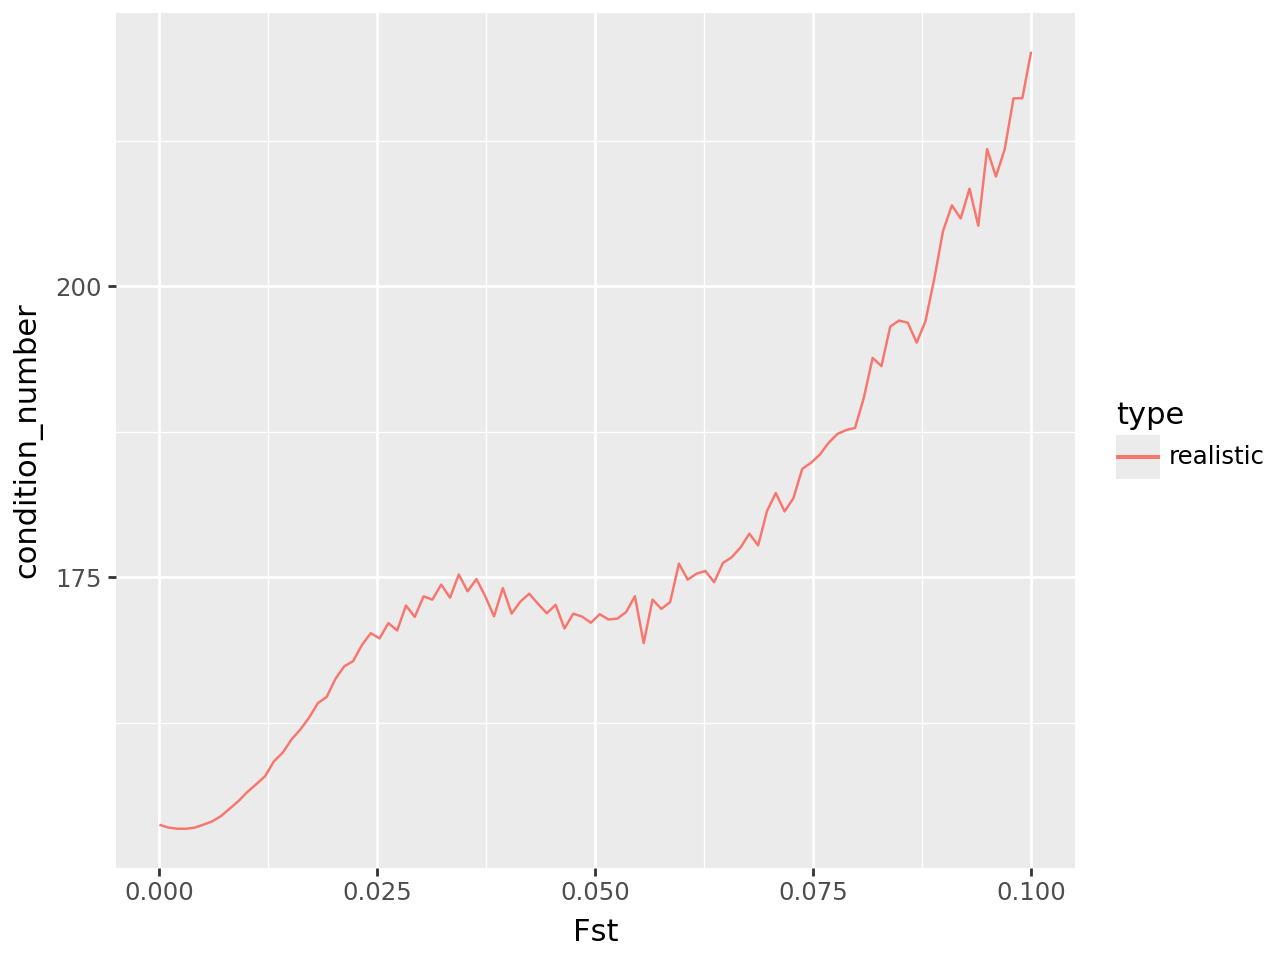

In [41]:
cond = pd.concat([AR1_cond,realistic_cond],axis = 0)

ggplot(cond[cond['type'] == 'realistic'],aes(x = 'Fst',y = 'condition_number',color = 'type')) + geom_line()